# **VII) FOMC Event Study**

Performs an Event Study that centers market data around FOMC announcement dates to isolate and visualize how monetary policy expectations shift when new official information is released to the public.


1. [**Import Data**](#1-import--data)
2. [**FOMC Meeting Dates**](#2-fomc)
3. [**Regime Classification**](#3-regime--class)
4. [**Aggregation & Plot**](#4-aggregation--plot)


### **1) Import Data** <a id="1-import--data"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/All_Data_Weekly_transformed.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

df[["mp_exp"]].dropna()

,mp_exp
date,
2014-09-21,-0.006073
2014-09-28,0.032847
2014-10-05,0.040000
2014-10-12,0.036765
2014-10-19,0.036932
...,...
2025-02-02,-0.051813
2025-02-09,-0.009174
2025-02-16,-0.275000


### **2) FOMC Meeting Dates** <a id="2-fomc"></a>

The source for FOMC meeting dates is the Federal Reserve Board’s official website:

https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm



In [2]:
# 2020 (Including Mar 3 and Mar 15 Emergency Meetings)
meeting_dates = pd.to_datetime([
    '2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18',
    '2014-07-30', '2014-09-17', '2014-10-29', '2014-12-17',
    '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17',
    '2015-07-29', '2015-09-17', '2015-10-28', '2015-12-16',
    '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15',
    '2016-07-27', '2016-09-21', '2016-11-02', '2016-12-14',
    '2017-02-01', '2017-03-15', '2017-05-03', '2017-06-14',
    '2017-07-26', '2017-09-20', '2017-11-01', '2017-12-13',
    '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13',
    '2018-08-01', '2018-09-26', '2018-11-08', '2018-12-19',
    '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19',
    '2019-07-31', '2019-09-18', '2019-10-30', '2019-12-11',
    '2020-01-29', '2020-03-03', '2020-03-15', '2020-04-29',
    '2020-06-10', '2020-07-29', '2020-09-16', '2020-11-05',
    '2020-12-16', '2021-01-27', '2021-03-17', '2021-04-28',
    '2021-06-16', '2021-07-28', '2021-09-22', '2021-11-03',
    '2021-12-15', '2022-01-26', '2022-03-16', '2022-05-04',
    '2022-06-15', '2022-07-27', '2022-09-21', '2022-11-02',
    '2022-12-14', '2023-02-01', '2023-03-22', '2023-05-03',
    '2023-06-14', '2023-07-26', '2023-09-20', '2023-11-01',
    '2023-12-13', '2024-01-31', '2024-03-20', '2024-05-01',
    '2024-06-12', '2024-07-31', '2024-09-18', '2024-11-07',
    '2024-12-18'
    # '2025-01-29',  '2025-03-19', '2025-05-07', '2025-06-18',
    # '2025-07-30', '2025-08-22', '2025-09-17', '2025-10-29',
    # '2025-12-10',
    # 2026 (Official Schedule)
    # '2026-01-28', '2026-03-18', '2026-04-29', '2026-06-17',
    # '2026-07-29', '2026-09-16', '2026-10-28', '2026-12-09'
]).sort_values()

meeting_dates

DatetimeIndex(['2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18',
               '2014-07-30', '2014-09-17', '2014-10-29', '2014-12-17',
               '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17',
               '2015-07-29', '2015-09-17', '2015-10-28', '2015-12-16',
               '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15',
               '2016-07-27', '2016-09-21', '2016-11-02', '2016-12-14',
               '2017-02-01', '2017-03-15', '2017-05-03', '2017-06-14',
               '2017-07-26', '2017-09-20', '2017-11-01', '2017-12-13',
               '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13',
               '2018-08-01', '2018-09-26', '2018-11-08', '2018-12-19',
               '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19',
               '2019-07-31', '2019-09-18', '2019-10-30', '2019-12-11',
               '2020-01-29', '2020-03-03', '2020-03-15', '2020-04-29',
               '2020-06-10', '2020-07-29', '2020-09-16', '2020-11-05',
      

### **3) Regime Classification** <a id="3-regime--class"></a>

Events are categorized by the average policy expectation in the 5 weeks prior to the meeting:
- **Hawkish**: Avg>0.01
- **Dovish**: Avg<−0.01
- **Neutral**: Between these thresholds.

In [3]:
window = 6  # +/- 5 weeks
results = {"Hawkish": [], "Neutral": [], "Dovish": []}

for m_date in meeting_dates:
    # Find the weekly index entry immediately following or on the FOMC date
    # This is t=0 for the event
    try:
        t0_idx = df.index.get_indexer([m_date], method='bfill')[0]
    except:
        continue

    # Ensure we have enough data for the full window (5 weeks before, 5 weeks after)
    if t0_idx >= window and (t0_idx + window) < len(df):
        # Extract the window slice (-5 to +5)
        window_slice = df.iloc[t0_idx - window : t0_idx + window + 1]["mp_exp"].values
        
        # Classification
        # Average of the index from t-5 to t-1 (indices 0 to 4 in our 11-point slice)
        pre_event_avg = np.mean(window_slice[0:5])
        
        if pre_event_avg > 0.01:
            label = "Dovish"
        elif pre_event_avg < -0.01:
            label = "Hawkish"
        else:
            label = "Neutral"
            
        results[label].append(window_slice)


### **4) Aggregation & Plot** <a id="4-aggregation--plot"></a>

Weekly Event Study: $MP_{exp}$ Reaction by Pre-Announcement Regime


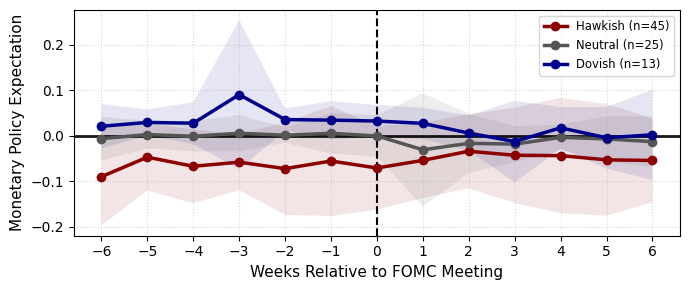

In [4]:
plt.figure(figsize=(7, 3))
colors = {"Hawkish": "#8b0000", "Neutral": "#555555", "Dovish": "#00008b"}
rel_weeks = np.arange(-window, window + 1)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5)#, label='FOMC Week (t=0)')
plt.axhline(0, color='black', linewidth=2, alpha=0.9)

for label, matrices in results.items():
    if not matrices:
        continue
        
    matrix = np.array(matrices)
    mean_path = np.mean(matrix, axis=0)
    std_path = np.std(matrix, axis=0)
    n_events = len(matrices)

    # Shaded Area (Standard Deviation)
    plt.fill_between(rel_weeks, mean_path - std_path, mean_path + std_path, 
                     color=colors[label], alpha=0.1, edgecolor='none')
    
    # Mean Line
    plt.plot(rel_weeks, mean_path, color=colors[label], marker='o', 
             linewidth=2.5, label=f"{label} (n={n_events})")

print("Weekly Event Study: $MP_{exp}$ Reaction by Pre-Announcement Regime")
plt.xlabel("Weeks Relative to FOMC Meeting", fontsize=11)
plt.ylabel("Monetary Policy Expectation", fontsize=11)
plt.xticks(rel_weeks)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True, loc='best', fontsize='small')
plt.tight_layout()
plt.savefig("figures/event_study_fomc.pdf")
plt.show()